## Using test df

[INFO] device: cuda
[INFO] Loading SOCAT TEST dataset: /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/pco2_test_data.csv
[INFO] Test rows used (after dropna): 7,599
[INFO] Loading scaler: /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/models/30S/trained_scaler.joblib

[INFO] Top models (by val_rmse):
   model  layer1  layer2  layer3   val_rmse  test_rmse
0     98      84      76      73  16.502820  17.555501
1     36      90      78      60  16.539656  17.526948
2     50      80      80      65  16.583527  17.661089
3    187      85      76      65  16.594350  17.522455
4     44      86      72      71  16.614320  17.571279
5      1      76      76      63  16.629737  17.428404
6    108      88      77      60  16.652715  17.505834
7    129      85      80      73  16.669108  17.738110
8    189      87      75      64  16.688093  17.497947
9    137      89      79      69  16.694392  17.299855

[INFO] Predicting

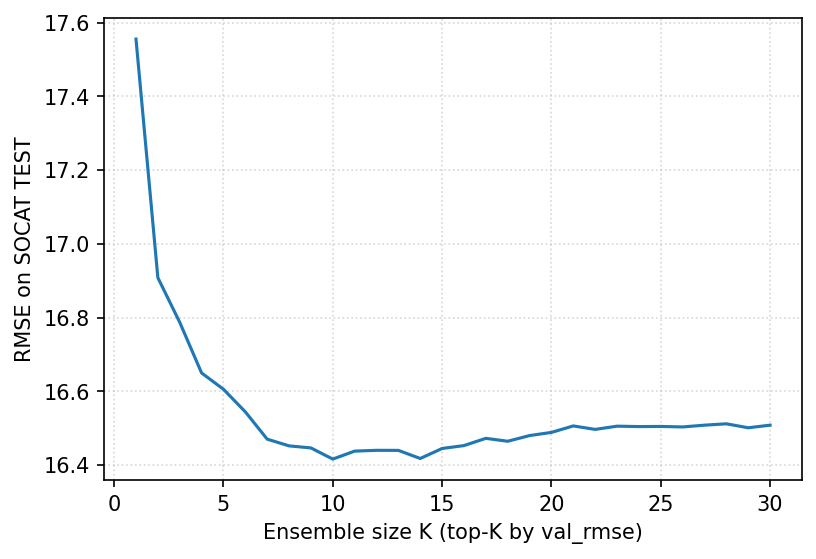


[INFO] First 15 K values:
     K  RMSE_test
0    1  17.555501
1    2  16.908132
2    3  16.787052
3    4  16.649620
4    5  16.605437
5    6  16.544117
6    7  16.470036
7    8  16.451801
8    9  16.446229
9   10  16.415963
10  11  16.437574
11  12  16.439732
12  13  16.439550
13  14  16.417598
14  15  16.444738

[INFO] Models used (in order):
    rank_by_val  layer1  layer2  layer3              file   val_rmse  \
0             1      84      76      73  MLP_84_76_73.pth  16.502820   
1             2      90      78      60  MLP_90_78_60.pth  16.539656   
2             3      80      80      65  MLP_80_80_65.pth  16.583527   
3             4      85      76      65  MLP_85_76_65.pth  16.594350   
4             5      86      72      71  MLP_86_72_71.pth  16.614320   
5             6      76      76      63  MLP_76_76_63.pth  16.629737   
6             7      88      77      60  MLP_88_77_60.pth  16.652715   
7             8      85      80      73  MLP_85_80_73.pth  16.669108   
8    

In [1]:
# ===============================================================
# Ensemble Size Sweep (Top-K models) on SOCAT TEST SET
# Predict with best 1, best 2, ... best K models (ranked by val_rmse)
# and compute RMSE on the SOCAT TEST split.
#
# Assumes you have:
#  - random_search_model_stats.csv in MODEL_DIR
#  - trained_scaler.joblib in MODEL_DIR
#  - pco2_test_data.csv in BASE_SPLIT_PATH
#  - model weights saved in MODEL_DIR as:
#       MLP_{l1}_{l2}_{l3}.pth   OR   MLP_{idx}_{l1}_{l2}_{l3}.pth
# ===============================================================

import os
import re
import numpy as np
import pandas as pd
import torch
import joblib
from torch import nn
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# -------------------------------
# CONFIG (SOCAT)
# -------------------------------
MODEL_DIR = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/models/30S/"
STATS_CSV = os.path.join(MODEL_DIR, "random_search_model_stats.csv")
SCALER_PATH = os.path.join(MODEL_DIR, "trained_scaler.joblib")

BASE_SPLIT_PATH = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/"
TEST_PATH = os.path.join(BASE_SPLIT_PATH, "pco2_test_data.csv")

TARGET_COL = "pco2"   # SOCAT target
TOP_MAX = 30          # evaluate ensembles of size 1..TOP_MAX

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] device:", device)

# Must match SOCAT training exactly (order matters!)
input_columns = [
    'SOCAT_temperature',
    'SOCAT_salinity',
    'MLD',
    'sla_median',
    'rrs412', 'rrs443', 'rrs490', 'rrs555', 'rrs670',
    'PAR_mean',
    'wind_speed',
    'atm_co2',
    'doy_sin',
    'doy_cos',
    'x_cart', 'y_cart', 'z_cart',
    'bottom_depth_m'
]

# -------------------------------
# LOAD TEST DATA
# -------------------------------
print(f"[INFO] Loading SOCAT TEST dataset: {TEST_PATH}")
test_df = pd.read_csv(TEST_PATH, low_memory=False)

missing = [c for c in input_columns + [TARGET_COL] if c not in test_df.columns]
if missing:
    raise ValueError(f"TEST CSV missing columns: {missing}")

test_df = test_df.dropna(subset=input_columns + [TARGET_COL]).copy()
y_true = test_df[TARGET_COL].to_numpy(dtype=float)

print(f"[INFO] Test rows used (after dropna): {len(test_df):,}")

# -------------------------------
# SCALE INPUTS
# -------------------------------
print(f"[INFO] Loading scaler: {SCALER_PATH}")
scaler = joblib.load(SCALER_PATH)

X_scaled = scaler.transform(test_df[input_columns].values)
x_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)

# -------------------------------
# READ STATS + PICK TOP-K BY VAL_RMSE
# -------------------------------
if not os.path.exists(STATS_CSV):
    raise FileNotFoundError(f"Stats file not found: {STATS_CSV}")

stats = pd.read_csv(STATS_CSV)

if "val_rmse" not in stats.columns:
    raise ValueError("stats CSV must contain a 'val_rmse' column.")
if not all(c in stats.columns for c in ["layer1", "layer2", "layer3"]):
    raise ValueError("stats CSV must contain layer1/layer2/layer3 columns.")

# deterministic tie-breaks (recommended)
tie_cols = [c for c in ["val_rmse", "test_rmse", "model"] if c in stats.columns]
stats = stats.sort_values(tie_cols, ascending=[True] * len(tie_cols)).reset_index(drop=True)

top = stats.head(TOP_MAX).copy()

print("\n[INFO] Top models (by val_rmse):")
cols_to_show = [c for c in ["model", "layer1", "layer2", "layer3", "val_rmse", "test_rmse"] if c in top.columns]
print(top[cols_to_show].head(10))

# -------------------------------
# MODEL DEFINITION (MATCH SOCAT TRAINING: TANH)
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, l1, l2, l3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, l1)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, l3)
        self.fc4 = nn.Linear(l3, 1)
        self.act = nn.Tanh()   # SOCAT random search used Tanh

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        return self.fc4(x)

def find_model_file(l1, l2, l3, model_dir):
    """
    Supports:
      - MLP_{l1}_{l2}_{l3}.pth
      - MLP_{idx}_{l1}_{l2}_{l3}.pth
    Returns filepath or None.
    """
    files = [f for f in os.listdir(model_dir) if f.endswith(".pth")]

    exact_old = f"MLP_{l1}_{l2}_{l3}.pth"
    if exact_old in files:
        return os.path.join(model_dir, exact_old)

    pattern = re.compile(rf"^MLP_\d+_{l1}_{l2}_{l3}\.pth$")
    matches = sorted([f for f in files if pattern.match(f)])
    if matches:
        return os.path.join(model_dir, matches[0])

    return None

# -------------------------------
# PREDICT EACH TOP MODEL
# -------------------------------
pred_list = []
used_meta = []

print("\n[INFO] Predicting with top models...")
for _, row in top.iterrows():
    l1, l2, l3 = int(row["layer1"]), int(row["layer2"]), int(row["layer3"])
    pth = find_model_file(l1, l2, l3, MODEL_DIR)

    if pth is None:
        print(f"[WARN] Missing .pth for arch {l1}-{l2}-{l3}. Skipping.")
        continue

    model = MLP(len(input_columns), l1, l2, l3).to(device)
    state = torch.load(pth, map_location=device)
    model.load_state_dict(state)
    model.eval()

    with torch.no_grad():
        pred = model(x_tensor).detach().cpu().numpy().reshape(-1)

    pred_list.append(pred)
    used_meta.append({
        "rank_by_val": len(used_meta) + 1,
        "layer1": l1, "layer2": l2, "layer3": l3,
        "file": os.path.basename(pth),
        "val_rmse": float(row["val_rmse"]),
        "test_rmse_reported": float(row["test_rmse"]) if "test_rmse" in row and pd.notna(row["test_rmse"]) else np.nan
    })

print(f"[INFO] Loaded/predicted {len(pred_list)} models out of requested {TOP_MAX}.")

if len(pred_list) == 0:
    raise RuntimeError("No models were loaded. Check MODEL_DIR and filenames.")

preds = np.stack(pred_list, axis=0)  # (n_models, n_samples)

# -------------------------------
# ENSEMBLE SIZE SWEEP
# -------------------------------
rmse_rows = []
best_k = None
best_rmse = np.inf

for k in range(1, preds.shape[0] + 1):
    ens_pred = preds[:k].mean(axis=0)
    rmse = np.sqrt(mean_squared_error(y_true, ens_pred))
    rmse_rows.append({"K": k, "RMSE_test": rmse})
    if rmse < best_rmse:
        best_rmse = rmse
        best_k = k

rmse_df = pd.DataFrame(rmse_rows)

print("\n[RESULT] Best ensemble size on SOCAT TEST:")
print(rmse_df.loc[rmse_df["RMSE_test"].idxmin()])

# -------------------------------
# PLOTS + OUTPUT TABLES
# -------------------------------
plt.figure(figsize=(6, 4), dpi=150)
plt.plot(rmse_df["K"], rmse_df["RMSE_test"])
plt.xlabel("Ensemble size K (top-K by val_rmse)")
plt.ylabel("RMSE on SOCAT TEST")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

used_df = pd.DataFrame(used_meta)

print("\n[INFO] First 15 K values:")
print(rmse_df.head(15))

print("\n[INFO] Models used (in order):")
print(used_df.head(20))

out_rmse_csv = os.path.join(MODEL_DIR, "ensemble_size_sweep_TEST_rmse.csv")
out_used_csv = os.path.join(MODEL_DIR, "ensemble_size_sweep_TEST_models_used.csv")

rmse_df.to_csv(out_rmse_csv, index=False)
used_df.to_csv(out_used_csv, index=False)

print(f"\n[SAVED] RMSE-by-K → {out_rmse_csv}")
print(f"[SAVED] Models-used → {out_used_csv}")


## Using independent df 

[INFO] device: cuda
[INFO] Loading SOCAT INDEPENDENT dataset: /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/processing_steps/independent_validation/pco2_independent_validation_data_regridded_SLA_RRS_PAR_WIND_ATM_CO2_feature_engineered_monthly_1deg_pCO2.csv
[INFO] Independent rows used (after dropna): 1,412
[INFO] Loading scaler: /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/models/30S/trained_scaler.joblib

[INFO] Top models (by val_rmse):
   model  layer1  layer2  layer3   val_rmse  test_rmse
0     98      84      76      73  16.502820  17.555501
1     36      90      78      60  16.539656  17.526948
2     50      80      80      65  16.583527  17.661089
3    187      85      76      65  16.594350  17.522455
4     44      86      72      71  16.614320  17.571279
5      1      76      76      63  16.629737  17.428404
6    108      88      77      60  16.652715  17.505834
7    129      85      80      73  16.669108  17.738110
8

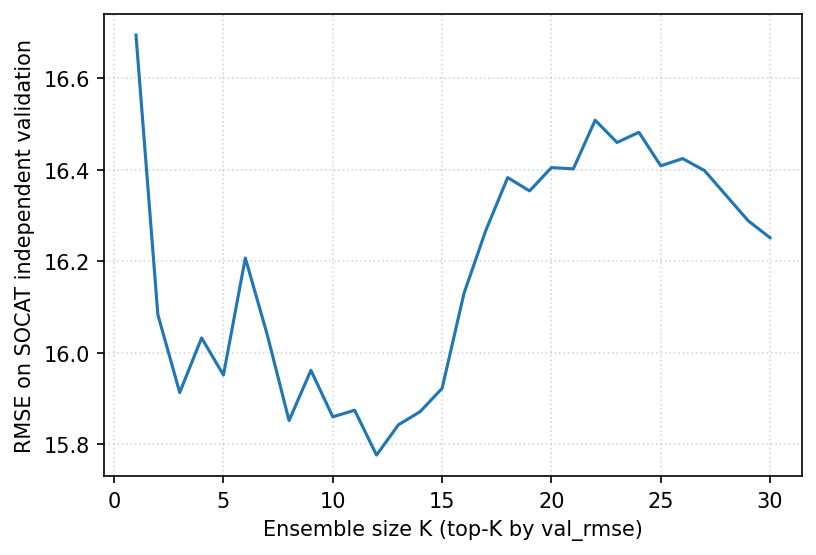


[INFO] First 15 K values:
     K  RMSE_indep
0    1   16.693981
1    2   16.083229
2    3   15.912939
3    4   16.032211
4    5   15.951179
5    6   16.206908
6    7   16.039774
7    8   15.851700
8    9   15.961424
9   10   15.859789
10  11   15.874208
11  12   15.776234
12  13   15.842239
13  14   15.871337
14  15   15.922063

[INFO] Models used (in order):
    rank_by_val  layer1  layer2  layer3              file   val_rmse  \
0             1      84      76      73  MLP_84_76_73.pth  16.502820   
1             2      90      78      60  MLP_90_78_60.pth  16.539656   
2             3      80      80      65  MLP_80_80_65.pth  16.583527   
3             4      85      76      65  MLP_85_76_65.pth  16.594350   
4             5      86      72      71  MLP_86_72_71.pth  16.614320   
5             6      76      76      63  MLP_76_76_63.pth  16.629737   
6             7      88      77      60  MLP_88_77_60.pth  16.652715   
7             8      85      80      73  MLP_85_80_73.pth  16

In [2]:
# ===============================================================
# Ensemble Size Sweep (Top-K models) on SOCAT INDEPENDENT VALIDATION SET
# Predict with best 1, best 2, ... best K models (ranked by val_rmse)
# and compute RMSE on the independent validation dataset.
#
# Assumes you have:
#  - random_search_model_stats.csv in MODEL_DIR
#  - trained_scaler.joblib in MODEL_DIR
#  - independent validation CSV with target + predictors
#  - model weights saved in MODEL_DIR as:
#       MLP_{l1}_{l2}_{l3}.pth   OR   MLP_{idx}_{l1}_{l2}_{l3}.pth
# ===============================================================

import os
import re
import numpy as np
import pandas as pd
import torch
import joblib
from torch import nn
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# -------------------------------
# CONFIG (SOCAT)
# -------------------------------
MODEL_DIR = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_SOCAT_ONLY_OBS_v2/models/30S/"
STATS_CSV = os.path.join(MODEL_DIR, "random_search_model_stats.csv")
SCALER_PATH = os.path.join(MODEL_DIR, "trained_scaler.joblib")

# >>> CHANGE THIS PATH IF NEEDED <<<
INDEP_PATH = (
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/"
    "MODEL_SOCAT_ONLY_OBS_v2/processing_steps/independent_validation/"
    "pco2_independent_validation_data_regridded_SLA_RRS_PAR_WIND_ATM_CO2_feature_engineered_monthly_1deg_pCO2.csv"
)

TARGET_COL = "pco2"   # SOCAT target
TOP_MAX = 30          # evaluate ensembles of size 1..TOP_MAX

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] device:", device)

# Must match SOCAT training exactly (order matters!)
input_columns = [
    'SOCAT_temperature',
    'SOCAT_salinity',
    'MLD',
    'sla_median',
    'rrs412', 'rrs443', 'rrs490', 'rrs555', 'rrs670',
    'PAR_mean',
    'wind_speed',
    'atm_co2',
    'doy_sin',
    'doy_cos',
    'x_cart', 'y_cart', 'z_cart',
    'bottom_depth_m'
]

# -------------------------------
# LOAD INDEPENDENT DATA
# -------------------------------
print(f"[INFO] Loading SOCAT INDEPENDENT dataset: {INDEP_PATH}")
indep_df = pd.read_csv(INDEP_PATH, low_memory=False)

missing = [c for c in input_columns + [TARGET_COL] if c not in indep_df.columns]
if missing:
    raise ValueError(f"Independent CSV missing columns: {missing}")

indep_df = indep_df.dropna(subset=input_columns + [TARGET_COL]).copy()
y_true = indep_df[TARGET_COL].to_numpy(dtype=float)

print(f"[INFO] Independent rows used (after dropna): {len(indep_df):,}")

# -------------------------------
# SCALE INPUTS
# -------------------------------
print(f"[INFO] Loading scaler: {SCALER_PATH}")
scaler = joblib.load(SCALER_PATH)

X_scaled = scaler.transform(indep_df[input_columns].values)
x_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)

# -------------------------------
# READ STATS + PICK TOP-K BY VAL_RMSE
# -------------------------------
if not os.path.exists(STATS_CSV):
    raise FileNotFoundError(f"Stats file not found: {STATS_CSV}")

stats = pd.read_csv(STATS_CSV)

if "val_rmse" not in stats.columns:
    raise ValueError("stats CSV must contain a 'val_rmse' column.")
if not all(c in stats.columns for c in ["layer1", "layer2", "layer3"]):
    raise ValueError("stats CSV must contain layer1/layer2/layer3 columns.")

# deterministic tie-breaks (recommended)
tie_cols = [c for c in ["val_rmse", "test_rmse", "model"] if c in stats.columns]
stats = stats.sort_values(tie_cols, ascending=[True] * len(tie_cols)).reset_index(drop=True)

top = stats.head(TOP_MAX).copy()

print("\n[INFO] Top models (by val_rmse):")
cols_to_show = [c for c in ["model", "layer1", "layer2", "layer3", "val_rmse", "test_rmse"] if c in top.columns]
print(top[cols_to_show].head(10))

# -------------------------------
# MODEL DEFINITION (MATCH SOCAT TRAINING: TANH)
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, l1, l2, l3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, l1)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, l3)
        self.fc4 = nn.Linear(l3, 1)
        self.act = nn.Tanh()  # SOCAT random search used Tanh

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        return self.fc4(x)

def find_model_file(l1, l2, l3, model_dir):
    """
    Supports:
      - MLP_{l1}_{l2}_{l3}.pth
      - MLP_{idx}_{l1}_{l2}_{l3}.pth
    Returns filepath or None.
    """
    files = [f for f in os.listdir(model_dir) if f.endswith(".pth")]

    exact_old = f"MLP_{l1}_{l2}_{l3}.pth"
    if exact_old in files:
        return os.path.join(model_dir, exact_old)

    pattern = re.compile(rf"^MLP_\d+_{l1}_{l2}_{l3}\.pth$")
    matches = sorted([f for f in files if pattern.match(f)])
    if matches:
        return os.path.join(model_dir, matches[0])

    return None

# -------------------------------
# PREDICT EACH TOP MODEL
# -------------------------------
pred_list = []
used_meta = []

print("\n[INFO] Predicting with top models...")
for _, row in top.iterrows():
    l1, l2, l3 = int(row["layer1"]), int(row["layer2"]), int(row["layer3"])
    pth = find_model_file(l1, l2, l3, MODEL_DIR)

    if pth is None:
        print(f"[WARN] Missing .pth for arch {l1}-{l2}-{l3}. Skipping.")
        continue

    model = MLP(len(input_columns), l1, l2, l3).to(device)
    state = torch.load(pth, map_location=device)
    model.load_state_dict(state)
    model.eval()

    with torch.no_grad():
        pred = model(x_tensor).detach().cpu().numpy().reshape(-1)

    pred_list.append(pred)
    used_meta.append({
        "rank_by_val": len(used_meta) + 1,
        "layer1": l1, "layer2": l2, "layer3": l3,
        "file": os.path.basename(pth),
        "val_rmse": float(row["val_rmse"]),
        "test_rmse_reported": float(row["test_rmse"]) if "test_rmse" in row and pd.notna(row["test_rmse"]) else np.nan
    })

print(f"[INFO] Loaded/predicted {len(pred_list)} models out of requested {TOP_MAX}.")

if len(pred_list) == 0:
    raise RuntimeError("No models were loaded. Check MODEL_DIR and filenames.")

preds = np.stack(pred_list, axis=0)  # (n_models, n_samples)

# -------------------------------
# ENSEMBLE SIZE SWEEP
# -------------------------------
rmse_rows = []
best_k = None
best_rmse = np.inf

for k in range(1, preds.shape[0] + 1):
    ens_pred = preds[:k].mean(axis=0)
    rmse = np.sqrt(mean_squared_error(y_true, ens_pred))
    rmse_rows.append({"K": k, "RMSE_indep": rmse})
    if rmse < best_rmse:
        best_rmse = rmse
        best_k = k

rmse_df = pd.DataFrame(rmse_rows)

print("\n[RESULT] Best ensemble size on SOCAT INDEPENDENT validation:")
print(rmse_df.loc[rmse_df["RMSE_indep"].idxmin()])

# -------------------------------
# PLOTS + OUTPUT TABLES
# -------------------------------
plt.figure(figsize=(6, 4), dpi=150)
plt.plot(rmse_df["K"], rmse_df["RMSE_indep"])
plt.xlabel("Ensemble size K (top-K by val_rmse)")
plt.ylabel("RMSE on SOCAT independent validation")
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

used_df = pd.DataFrame(used_meta)

print("\n[INFO] First 15 K values:")
print(rmse_df.head(15))

print("\n[INFO] Models used (in order):")
print(used_df.head(20))

out_rmse_csv = os.path.join(MODEL_DIR, "ensemble_size_sweep_INDEP_rmse.csv")
out_used_csv = os.path.join(MODEL_DIR, "ensemble_size_sweep_INDEP_models_used.csv")

rmse_df.to_csv(out_rmse_csv, index=False)
used_df.to_csv(out_used_csv, index=False)

print(f"\n[SAVED] RMSE-by-K → {out_rmse_csv}")
print(f"[SAVED] Models-used → {out_used_csv}")
